# Multimodal Classification: Zero-Shot vs Few-Shot Learning

**Assignment 1 - Deep Learning and Its Applications (CO3133)**


## 1. Environment Setup


In [1]:
import sys

print(sys.version)
print(sys.executable)

# 1. Force update the core build tools
!{sys.executable} -m pip install --upgrade pip setuptools wheel

# 2. Fix the specific 'backports' conflict
!{sys.executable} -m pip uninstall -y backports.tarfile
!{sys.executable} -m pip install backports.tarfile
!{sys.executable} -m pip install -q torch torchvision torchaudio
!{sys.executable} -m pip install -q transformers datasets accelerate pillow
!{sys.executable} -m pip install -q scikit-learn matplotlib seaborn tqdm
!{sys.executable} -m pip install -q pandas numpy pycocotools
# Model CLIP (From OPENAI)
!{sys.executable} -m pip install -q https://github.com/openai/CLIP/archive/refs/heads/main.zip


3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
/usr/bin/python3
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 39.6 MB/s eta 0:00:00
  Attempting uninstall: setuptools
    Found existing installation: setuptools 75.2.0
    Uninstalling setuptools-75.2.0:
      Successfully uninstalled setuptools-75.2.0
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


Import Libraries and Device Configuration

In [2]:
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import clip
from PIL import Image
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import os
import json
from typing import List, Tuple, Dict
import warnings
from collections import defaultdict
warnings.filterwarnings('ignore')

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


## 2. Load CLIP Model and Download Dataset (10 Classes from UPMC-101 Food)

In [3]:
# Load CLIP model
print("Loading CLIP model...")
model_name = "ViT-B/16"
model_base, transform = clip.load(model_name, device=device)
model_base.eval()
print(f"CLIP model {model_name} loaded successfully!")
print(f"Model parameters: {sum(p.numel() for p in model_base.parameters())/1e6:.2f}M")
print(transform)



Loading CLIP model...


100%|███████████████████████████████████████| 335M/335M [00:06<00:00, 50.2MiB/s]


CLIP model ViT-B/16 loaded successfully!
Model parameters: 149.62M
Compose(
    Resize(size=224, interpolation=bicubic, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    <function _convert_image_to_rgb at 0x7aa07d6a49a0>
    ToTensor()
    Normalize(mean=(0.48145466, 0.4578275, 0.40821073), std=(0.26862954, 0.26130258, 0.27577711))
)


In [4]:
from torchvision import transforms

clip_mean = (0.48145466, 0.4578275, 0.40821073)
clip_std  = (0.26862954, 0.26130258, 0.27577711)

# Không augmentation
train_transform_no_aug = transform

# Có augmentation
train_transform_aug = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomApply([
        transforms.ColorJitter(0.15, 0.15, 0.15, 0.03)
    ], p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(clip_mean, clip_std),
])

# Validation / Test luôn giữ cố định
test_transform_clip = transform

In [5]:
import os
import zipfile
import subprocess

file_id = "19SsVYSMYGkciQyqfArAYZkvsbmiS1N8A"
zip_path = "/content/data.zip"
extract_dir = "/content/data"

subprocess.run(["pip", "-q", "install", "gdown"], check=False)

# Download data
subprocess.run(["gdown", "--id", file_id, "-O", zip_path], check=True)

# Unzip
os.makedirs(extract_dir, exist_ok=True)
with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_dir)




DATASET_ROOT = "/content/data/data"

train_dir = os.path.join(DATASET_ROOT, "train")
test_dir = os.path.join(DATASET_ROOT, "test")

train_csv = os.path.join(DATASET_ROOT, "texts", "train_titles.csv")
test_csv = os.path.join(DATASET_ROOT, "texts", "test_titles.csv")

lines = [
    f"train_dir: {train_dir}",
    f"test_dir : {test_dir}",
    f"train_csv: {train_csv}",
    f"test_csv : {test_csv}",
    "",
    f"train_dir exists: {os.path.exists(train_dir)}",
    f"test_dir exists : {os.path.exists(test_dir)}",
    f"train_csv exists: {os.path.exists(train_csv)}",
    f"test_csv exists : {os.path.exists(test_csv)}",
]


## 3. Dataset Setup and Preprocessing

In [6]:

from torch.utils.data import Dataset

class MultimodalDataset(Dataset):
    def __init__(self, image_paths, texts, labels, transform=None):
        self.image_paths = image_paths
        self.texts = texts
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        text = str(self.texts[idx])
        label = int(self.labels[idx])

        return image, text, label

In [7]:

import os
from sklearn.model_selection import train_test_split

# Create lists of classes
class_names = sorted([
    d for d in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, d))
])
num_classes = len(class_names)
print(f"Classes ({num_classes}): {class_names}")
#Label Encoding
label2id = {c: i for i, c in enumerate(class_names)}
#Label Decoding
id2label = {i: c for c, i in label2id.items()}

# Processing file CSV
def load_title_map(csv_path: str) -> dict:
    title_map = {}
    with open(csv_path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.rsplit(",", 2)   # filename, title, label
            if len(parts) != 3:
                continue
            fname, title, lbl = parts
            title_map[fname] = title
    return title_map

train_title_map = load_title_map(train_csv)
test_title_map = load_title_map(test_csv)

print(f"Train titles: {len(train_title_map)}")
print(f"Test titles:  {len(test_title_map)}")

# ===== 3) Thu thập dữ liệu từ train/test =====
def collect_split(split_dir: str, title_map: dict):
    image_paths, texts, labels = [], [], []
    missing_title = 0

    for cls in class_names:
        cls_dir = os.path.join(split_dir, cls)
        if not os.path.isdir(cls_dir):
            continue

        for fn in os.listdir(cls_dir):
            if not fn.lower().endswith((".jpg", ".jpeg", ".png", ".webp")):
                continue

            path = os.path.join(cls_dir, fn)
            image_paths.append(path)
            labels.append(label2id[cls])

            title = title_map.get(fn)
            if title is None:
                missing_title += 1
                title = f"a photo of {cls.replace('_', ' ')}"
            texts.append(title)

    return image_paths, texts, labels, missing_title

train_paths, train_texts, train_labels, train_missing = collect_split(train_dir, train_title_map)
test_paths, test_texts, test_labels, test_missing = collect_split(test_dir, test_title_map)

print(f"Train images: {len(train_paths)} | missing titles: {train_missing}")
print(f"Test images:  {len(test_paths)} | missing titles: {test_missing}")

#Split data train/val
VAL_RATIO = 0.1

X_train = list(zip(train_paths, train_texts))
X_test = list(zip(test_paths, test_texts))

X_tr, X_va, y_tr, y_va = train_test_split(
    X_train,
    train_labels,
    test_size=VAL_RATIO,
    random_state=42,
    stratify=train_labels
)

image_paths_train, texts_train = zip(*X_tr)
image_paths_val, texts_val = zip(*X_va)
image_paths_test, texts_test = zip(*X_test)

image_paths_train = list(image_paths_train)
texts_train = list(texts_train)
image_paths_val = list(image_paths_val)
texts_val = list(texts_val)
image_paths_test = list(image_paths_test)
texts_test = list(texts_test)

labels_train = list(y_tr)
labels_val = list(y_va)
labels_test = list(test_labels)

image_paths = train_paths

print("Split done:")
print(f"train: {len(labels_train)}")
print(f"-val:   {len(labels_val)}")
print(f"test:  {len(labels_test)}")

Classes (10): ['donuts', 'french_fries', 'hamburger', 'hot_dog', 'ice_cream', 'pho', 'pizza', 'steak', 'sushi', 'tacos']
Train titles: 67988
Test titles:  22716
Train images: 6866 | missing titles: 0
Test images:  2295 | missing titles: 0
Split done:
train: 6179
-val:   687
test:  2295


In [8]:
#Dataloader Existence
train_dataset = MultimodalDataset(list(image_paths_train), list(texts_train), labels_train, transform=transform)
val_dataset = MultimodalDataset(list(image_paths_val), list(texts_val), labels_val, transform=transform)
test_dataset = MultimodalDataset(list(image_paths_test), list(texts_test), labels_test, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

print("DataLoaders created successfully with transforms!")

DataLoaders created successfully with transforms!


The multimodal dataset consists of genuine image–text pairs describing the same entity/event, as required by the assignment. For the multimodal task, both zero-shot and few-shot settings are implemented on paired image–text inputs to remain consistent with the multimodal nature of the datase



## 4. Zero-Shot Classification

Zero-shot classification use CLIP model , no fine-tuning phrase


In [9]:
import torch
import numpy as np
from tqdm import tqdm

class ZeroShotClassifier:
    def __init__(self, clip_model, class_names, device="cuda"):
        self.model = clip_model
        self.class_names = class_names
        self.device = device

        # Prompt embedding
        self.class_texts = [f"a photo of {name.replace('_', ' ')}" for name in class_names]

        self.model.eval()
        with torch.no_grad():
            self.text_tokens = clip.tokenize(self.class_texts, truncate=True).to(self.device)
            self.class_features = self.model.encode_text(self.text_tokens)
            self.class_features = self.class_features / self.class_features.norm(dim=-1, keepdim=True)

    def predict(self, image, text_caption):
        """
        Zero-shot multimodal prediction with image + paired text
        """
        self.model.eval()

        with torch.no_grad():
            # Encode image
            image_input = image.unsqueeze(0).to(self.device)
            image_features = self.model.encode_image(image_input)
            image_features = image_features / image_features.norm(dim=-1, keepdim=True)

            # Encode paired text caption
            text_tokens = clip.tokenize([str(text_caption)], truncate=True).to(self.device)
            text_features = self.model.encode_text(text_tokens)
            text_features = text_features / text_features.norm(dim=-1, keepdim=True)

            # Fusion image + text
            combined_features = (image_features + text_features) / 2.0
            combined_features = combined_features / combined_features.norm(dim=-1, keepdim=True)

            # Comparision with class prompt embeddings
            logits = 100.0 * combined_features @ self.class_features.T
            probs = logits.softmax(dim=-1)

            confidence, pred_idx = probs[0].max(dim=0)

            return pred_idx.item(), confidence.item(), probs[0].cpu().numpy()

    def evaluate(self, dataloader):
        """
        Evaluate on  dataset multimodal
        """
        self.model.eval()
        all_preds = []
        all_labels = []
        all_confidences = []

        with torch.no_grad():
            for images, texts, labels in tqdm(dataloader, desc="Zero-shot evaluation"):
                images = images.to(self.device)

                for i in range(len(images)):
                    pred_idx, confidence, _ = self.predict(images[i], texts[i])
                    all_preds.append(pred_idx)
                    all_labels.append(labels[i].item())
                    all_confidences.append(confidence)

        return np.array(all_preds), np.array(all_labels), np.array(all_confidences)

In [10]:
if len(image_paths) > 0:
    print("ZERO-SHOT CLASSIFICATION")

    zero_shot_classifier = ZeroShotClassifier(model_base, class_names, device=device)

    print("\nEvaluating zero-shot classifier...")
    preds_zero_shot, labels_zero_shot, confidences_zero_shot = zero_shot_classifier.evaluate(
        test_loader
    )

    accuracy_zero_shot = accuracy_score(labels_zero_shot, preds_zero_shot)
    f1_zero_shot = f1_score(labels_zero_shot, preds_zero_shot, average='weighted')

    print(f"\nZero-Shot Results:")
    print(f"Accuracy: {accuracy_zero_shot:.4f}")
    print(f"F1 Score (weighted): {f1_zero_shot:.4f}")
    print("\nClassification Report:")
    print(classification_report(labels_zero_shot, preds_zero_shot, target_names=class_names))
else:
    print("Please load dataset first!")

ZERO-SHOT CLASSIFICATION

Evaluating zero-shot classifier...


Zero-shot evaluation: 100%|██████████| 36/36 [00:59<00:00,  1.65s/it]


Zero-Shot Results:
Accuracy: 0.8959
F1 Score (weighted): 0.8769

Classification Report:
              precision    recall  f1-score   support

      donuts       0.97      0.94      0.96       232
french_fries       0.91      0.97      0.94       212
   hamburger       0.90      0.87      0.88       233
     hot_dog       0.90      0.26      0.40       234
   ice_cream       0.94      0.99      0.96       232
         pho       0.90      0.98      0.94       218
       pizza       0.84      1.00      0.91       235
       steak       0.86      0.98      0.92       229
       sushi       0.85      0.99      0.92       237
       tacos       0.91      0.99      0.95       233

    accuracy                           0.90      2295
   macro avg       0.90      0.90      0.88      2295
weighted avg       0.90      0.90      0.88      2295



## 5. Few-Shot Classification

Few-shot CLIP-based Classification ( 1-shot,5-shot,10-shot)

In [11]:
def make_k_shot_subset(image_paths, texts, labels, k=1, seed=42):
    rng = random.Random(seed)

    per_class = defaultdict(list)
    for img, txt, lb in zip(image_paths, texts, labels):
        per_class[lb].append((img, txt, lb))

    few_img, few_txt, few_lb = [], [], []

    for lb, samples in per_class.items():
        rng.shuffle(samples)

        if len(samples) < k:
            print(f"[WARN] Class {lb} chỉ có {len(samples)} mẫu, nhỏ hơn k={k}")

        chosen = samples[:k]

        for img, txt, y in chosen:
            few_img.append(img)
            few_txt.append(txt)
            few_lb.append(y)

    return few_img, few_txt, few_lb

In [12]:
class FewShotClassifier(nn.Module):
    def __init__(self, clip_model, num_classes, device="cuda"):
        super().__init__()
        self.clip_model = clip_model
        self.device = device

        # Freeze CLIP encoder
        self.clip_model.eval()
        for p in self.clip_model.parameters():
            p.requires_grad = False

        feature_dim = clip_model.visual.output_dim
        input_dim = feature_dim * 2   # image + text

        print(f"[INIT] feature_dim={feature_dim}, input_dim={input_dim}, num_classes={num_classes}")

        # Classifier head for few-shot learning
        self.classifier = nn.Linear(input_dim, num_classes)

    def forward(self, images, texts):
        # Encode bằng CLIP, không train encoder
        with torch.no_grad():
            image_features = self.clip_model.encode_image(images)
            image_features = image_features / image_features.norm(dim=-1, keepdim=True)

            cleaned_texts = [str(t) for t in texts]
            text_tokens = clip.tokenize(cleaned_texts, truncate=True).to(images.device)

            text_features = self.clip_model.encode_text(text_tokens)
            text_features = text_features / text_features.norm(dim=-1, keepdim=True)

            features = torch.cat([image_features, text_features], dim=1)

        logits = self.classifier(features.float())
        return logits


In [13]:
class PrototypeFewShotClassifier(nn.Module):
    def __init__(self, clip_model, num_classes, device="cuda"):
        super().__init__()
        self.clip_model = clip_model
        self.num_classes = num_classes
        self.device = device

        self.clip_model.eval()
        for p in self.clip_model.parameters():
            p.requires_grad = False

        self.register_buffer("prototypes", None)

    def extract_features(self, images, texts):
        with torch.no_grad():
            image_features = self.clip_model.encode_image(images)
            image_features = image_features / image_features.norm(dim=-1, keepdim=True)

            cleaned_texts = [str(t) for t in texts]
            text_tokens = clip.tokenize(cleaned_texts, truncate=True).to(images.device)
            text_features = self.clip_model.encode_text(text_tokens)
            text_features = text_features / text_features.norm(dim=-1, keepdim=True)

            features = torch.cat([image_features, text_features], dim=1)
            features = features / features.norm(dim=-1, keepdim=True)
        return features.float()

    def fit_prototypes(self, train_loader):
        self.eval()
        feats_per_class = {c: [] for c in range(self.num_classes)}

        with torch.no_grad():
            for images, texts, labels in tqdm(train_loader, desc="Building prototypes"):
                images = images.to(self.device)
                labels = labels.to(self.device)
                features = self.extract_features(images, texts)

                for c in range(self.num_classes):
                    mask = (labels == c)
                    if mask.any():
                        feats_per_class[c].append(features[mask])

        proto_list = []
        feature_dim = None
        for c in range(self.num_classes):
            if len(feats_per_class[c]) > 0:
                cls_feats = torch.cat(feats_per_class[c], dim=0)
                proto = cls_feats.mean(dim=0, keepdim=True)
                proto = proto / proto.norm(dim=-1, keepdim=True)
                proto_list.append(proto)
                feature_dim = proto.shape[-1]
            else:
                if feature_dim is None:
                    feature_dim = self.clip_model.visual.output_dim * 2
                proto = torch.zeros(1, feature_dim, device=self.device)
                proto_list.append(proto)

        self.prototypes = torch.cat(proto_list, dim=0)

    def forward(self, images, texts):
        features = self.extract_features(images, texts)
        logits = 100.0 * features @ self.prototypes.T
        return logits



In [14]:
#Train
def train_few_shot(
    model,
    train_loader,
    val_loader,
    num_epochs=10,
    lr=1e-4,
    device="cuda",
    save_path="best_few_shot_model.pth",
    patience=8,
    min_delta=1e-3
):
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.classifier.parameters(), lr=lr)

    train_losses = []
    val_accuracies = []
    best_val_acc = -float("inf")
    best_epoch = -1
    epochs_no_improve = 0

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0

        for images, texts, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            logits = model(images, texts)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_train_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation
        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for images, texts, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                logits = model(images, texts)
                preds = torch.argmax(logits, dim=1)

                total += labels.size(0)
                correct += (preds == labels).sum().item()

        val_acc = correct / total if total > 0 else 0.0
        val_accuracies.append(val_acc)

        print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {avg_train_loss:.4f} - Val Acc: {val_acc:.4f}")

        if val_acc > (best_val_acc + min_delta):
            best_val_acc = val_acc
            best_epoch = epoch + 1
            epochs_no_improve = 0
            torch.save(model.state_dict(), save_path)
            print(f"[SAVE] Best model saved to: {save_path} | best_val_acc={best_val_acc:.4f}")
        else:
            epochs_no_improve += 1
            print(f"[EARLY_STOP] no improvement: {epochs_no_improve}/{patience}")

        if epochs_no_improve >= patience:
            print(
                f"[EARLY_STOP] Stop at epoch {epoch+1}. "
                f"Best epoch: {best_epoch}, best_val_acc: {best_val_acc:.4f}"
            )
            break

    return train_losses, val_accuracies


In [15]:
#Evaluate on test set
def evaluate_few_shot(model, data_loader, device="cuda"):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, texts, labels in tqdm(data_loader, desc="Few-shot Test Eval"):
            images = images.to(device)

            logits = model(images, texts)
            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    acc = (all_preds == all_labels).mean()
    f1 = f1_score(all_labels, all_preds, average="weighted")

    return acc, f1, all_preds, all_labels

In [16]:
# =========================
# 6) RUN ONE FEW-SHOT EXPERIMENT
# =========================
def run_few_shot_experiment(
    clip_model,
    num_classes,
    k,
    image_paths_train,
    texts_train,
    labels_train,
    image_paths_val,
    texts_val,
    labels_val,
    train_transform,
    test_transform,
    num_epochs=25,
    lr=1e-4,
    batch_size=16,
    device="cuda",
    seed=42,
    patience=8,
    min_delta=1e-3
):
    # K-shot subset
    few_train_paths, few_train_texts, few_train_labels = make_k_shot_subset(
        image_paths_train, texts_train, labels_train, k=k, seed=seed
    )

    print(f"[INFO] Running {k}-shot with {len(few_train_labels)} samples")

    # Dataset
    train_dataset = MultimodalDataset(
        few_train_paths, few_train_texts, few_train_labels, transform=train_transform
    )
    val_dataset = MultimodalDataset(
        image_paths_val, texts_val, labels_val, transform=test_transform
    )

    # Loader
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # Model
    model = FewShotClassifier(clip_model, num_classes=num_classes, device=device)

    # Unique checkpoint for each k
    save_path = f"best_few_shot_{k}shot.pth"

    # Train
    train_losses, val_accuracies = train_few_shot(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        num_epochs=num_epochs,
        lr=lr,
        device=device,
        save_path=save_path,
        patience=patience,
        min_delta=min_delta
    )

    # Load best checkpoint before test
    model.load_state_dict(torch.load(save_path, map_location=device))
    model = model.to(device)
    model.eval()

    return model, train_losses, val_accuracies


In [17]:
def run_prototype_experiment(
    clip_model,
    num_classes,
    k,
    image_paths_train,
    texts_train,
    labels_train,
    image_paths_val,
    texts_val,
    labels_val,
    train_transform,
    test_transform,
    batch_size=16,
    device="cuda",
    seed=42
):
    few_train_paths, few_train_texts, few_train_labels = make_k_shot_subset(
        image_paths_train, texts_train, labels_train, k=k, seed=seed
    )

    print(f"[INFO] Prototype {k}-shot with {len(few_train_labels)} samples")

    train_dataset = MultimodalDataset(
        few_train_paths, few_train_texts, few_train_labels, transform=train_transform
    )
    val_dataset = MultimodalDataset(
        image_paths_val, texts_val, labels_val, transform=test_transform
    )

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    model = PrototypeFewShotClassifier(clip_model, num_classes=num_classes, device=device).to(device)
    model.fit_prototypes(train_loader)

    return model, train_loader, val_loader



In [19]:
results_aug_compare = {}

settings = {
    "no_aug": train_transform_no_aug,
    "aug": train_transform_aug
}

for setting_name, train_tf in settings.items():
    print(f"SETTING: {setting_name}")

    results_aug_compare[setting_name] = {}

    for k in [5, 10]:
        print(f"RUNNING {k}-SHOT")

        # 1) Prototype first
        proto_model, _, _ = run_prototype_experiment(
            clip_model=model_base,
            num_classes=num_classes,
            k=k,
            image_paths_train=image_paths_train,
            texts_train=texts_train,
            labels_train=labels_train,
            image_paths_val=image_paths_val,
            texts_val=texts_val,
            labels_val=labels_val,
            train_transform=train_tf,
            test_transform=test_transform_clip,
            batch_size=16,
            device=device,
            seed=42
        )

        acc_proto, f1_proto, preds_proto, labels_proto = evaluate_few_shot(
            proto_model,
            test_loader,
            device=device
        )

        # 2) Linear classifier
        few_model, train_losses, val_accuracies = run_few_shot_experiment(
            clip_model=model_base,
            num_classes=num_classes,
            k=k,
            image_paths_train=image_paths_train,
            texts_train=texts_train,
            labels_train=labels_train,
            image_paths_val=image_paths_val,
            texts_val=texts_val,
            labels_val=labels_val,
            train_transform=train_tf,
            test_transform=test_transform_clip,
            num_epochs=50,
            lr=1e-4,
            batch_size=16,
            device=device,
            seed=42,
            patience=8,
            min_delta=1e-3
        )

        acc_k, f1_k, preds_k, labels_k = evaluate_few_shot(
            few_model,
            test_loader,
            device=device
        )

        results_aug_compare[setting_name][k] = {
            "prototype": {
                "model": proto_model,
                "accuracy": acc_proto,
                "f1": f1_proto,
                "preds": preds_proto,
                "labels": labels_proto
            },
            "linear": {
                "model": few_model,
                "accuracy": acc_k,
                "f1": f1_k,
                "preds": preds_k,
                "labels": labels_k,
                "train_losses": train_losses,
                "val_accuracies": val_accuracies
            },
            # keep backward-compatible top-level keys as linear
            "model": few_model,
            "accuracy": acc_k,
            "f1": f1_k,
            "preds": preds_k,
            "labels": labels_k,
            "train_losses": train_losses,
            "val_accuracies": val_accuracies
        }

        print(f"{setting_name} | {k}-Shot | PROTOTYPE Acc: {acc_proto:.4f} | F1: {f1_proto:.4f}")
        print(f"{setting_name} | {k}-Shot | LINEAR    Acc: {acc_k:.4f} | F1: {f1_k:.4f}")



SETTING: no_aug
RUNNING 5-SHOT
[INFO] Prototype 5-shot with 50 samples


Few-shot Test Eval: 100%|██████████| 36/36 [00:17<00:00,  2.08it/s]


[INFO] Running 5-shot with 50 samples
[INIT] feature_dim=512, input_dim=1024, num_classes=10


Epoch 1/50: 100%|██████████| 4/4 [00:00<00:00,  7.94it/s]


Epoch [1/50] - Train Loss: 2.3018 - Val Acc: 0.0873
[SAVE] Best model saved to: best_few_shot_5shot.pth | best_val_acc=0.0873


...

Epoch [49/50] - Train Loss: 2.0951 - Val Acc: 0.8908
[EARLY_STOP] no improvement: 3/8


Epoch 50/50: 100%|██████████| 7/7 [00:01<00:00,  6.15it/s]


Epoch [50/50] - Train Loss: 2.0951 - Val Acc: 0.8967
[SAVE] Best model saved to: best_few_shot_10shot.pth | best_val_acc=0.8967


Few-shot Test Eval: 100%|██████████| 36/36 [00:17<00:00,  2.10it/s]

aug | 10-Shot | PROTOTYPE Acc: 0.9251 | F1: 0.9262
aug | 10-Shot | LINEAR    Acc: 0.8919 | F1: 0.8888


## 6. So sánh kết quả và Visualization

RN50 COMPARISON: Few-shot (5 vs 10) | Prototype vs Linear | no_aug vs aug
Backbone  Shot Setting    Method  Accuracy  Precision  F1 Score
    RN50     5     aug    Linear    0.7346     0.8302    0.7286
    RN50     5     aug Prototype    0.8741     0.8842    0.8751
    RN50     5  no_aug    Linear    0.7895     0.8323    0.7891
    RN50     5  no_aug Prototype    0.8837     0.8944    0.8855
    RN50    10     aug    Linear    0.8919     0.9032    0.8888
    RN50    10     aug Prototype    0.9251     0.9299    0.9262
    RN50    10  no_aug    Linear    0.8898     0.9027    0.8885
    RN50    10  no_aug Prototype    0.9207     0.9263    0.9218


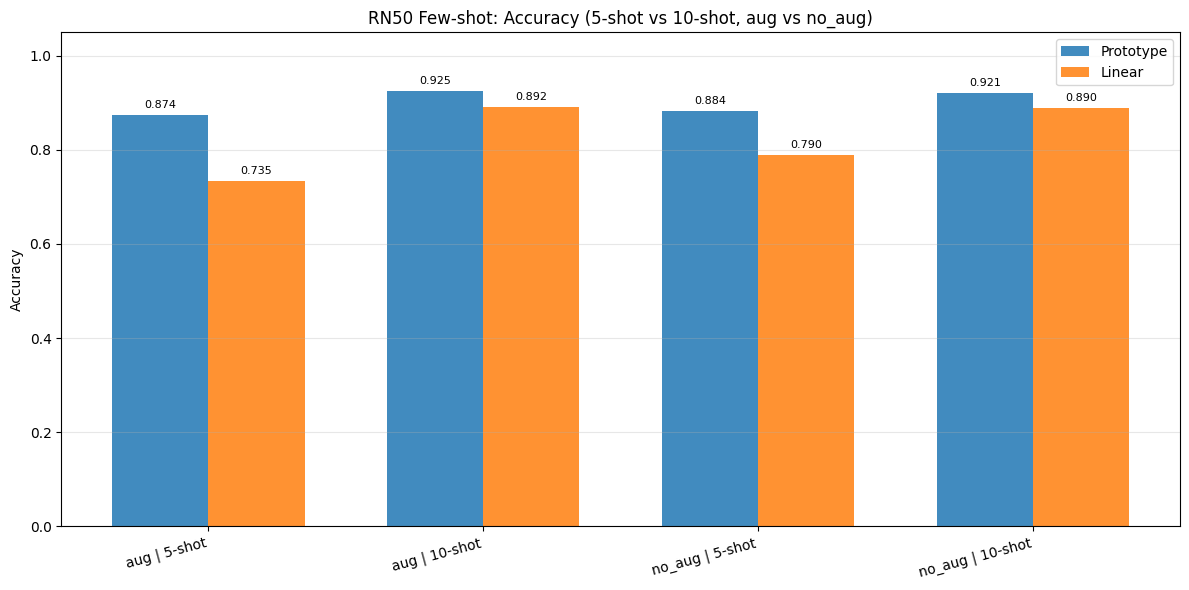

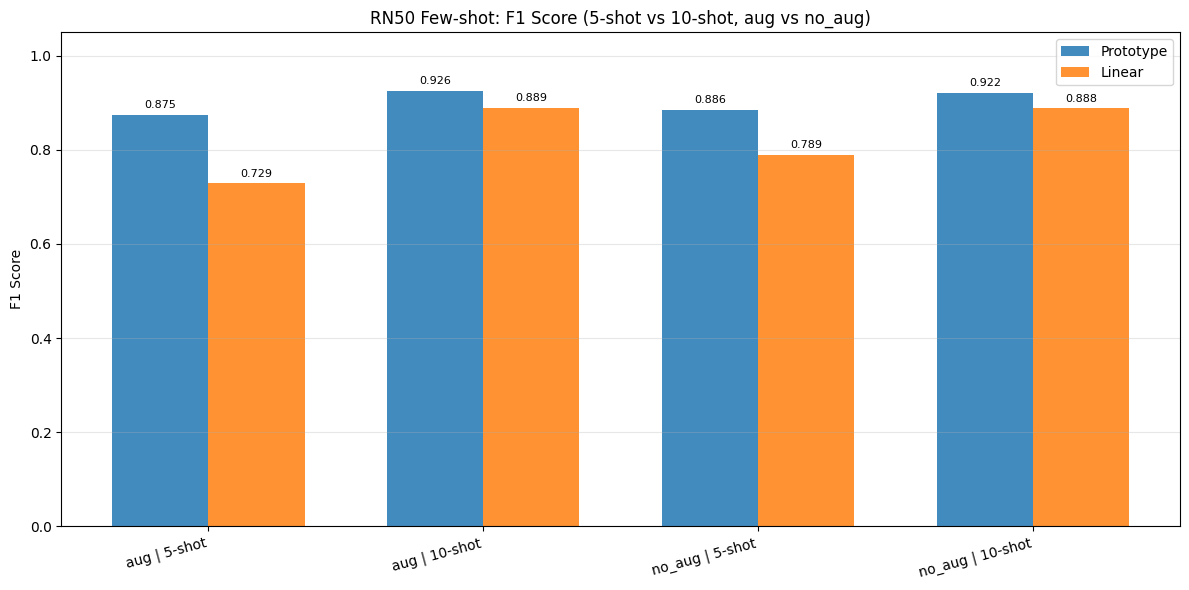

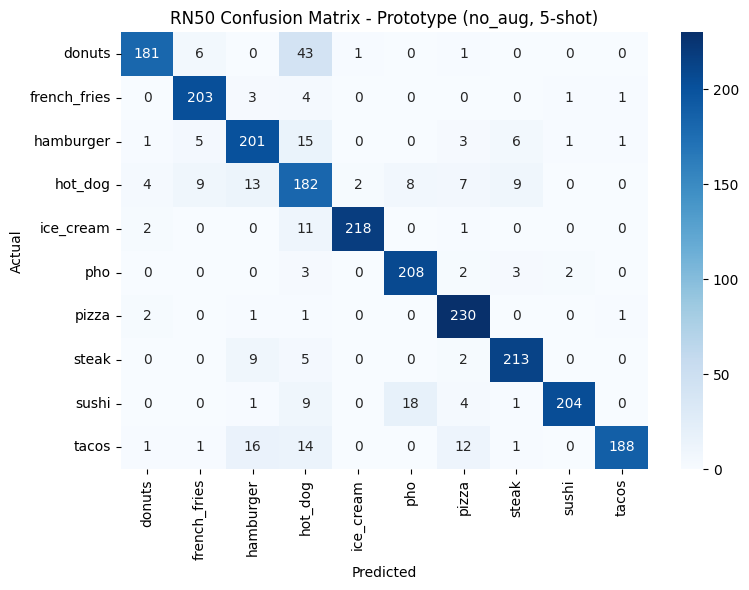

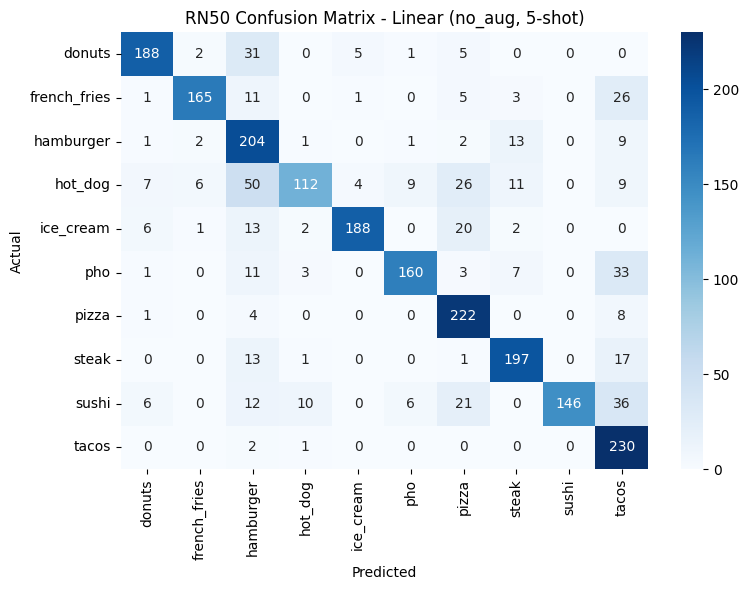

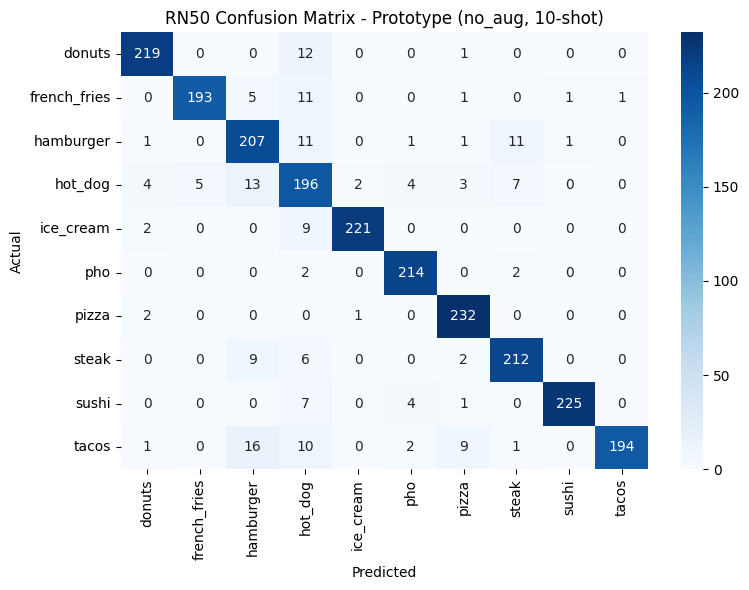

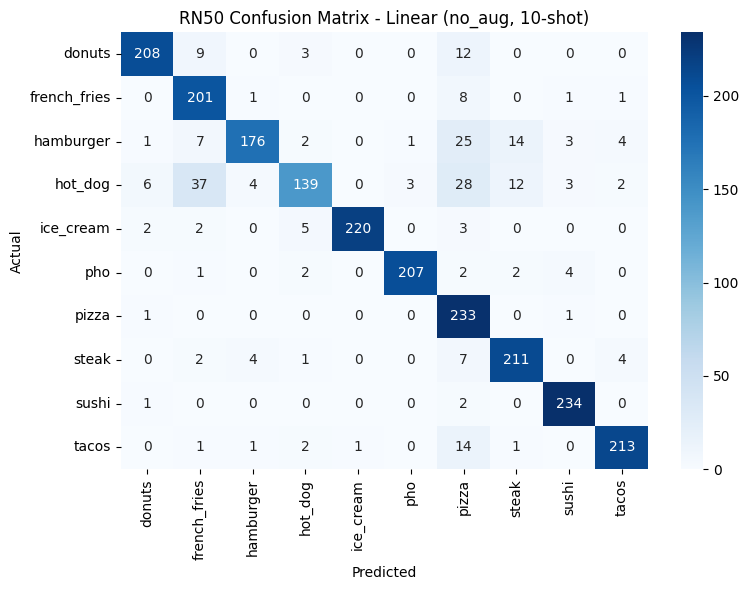

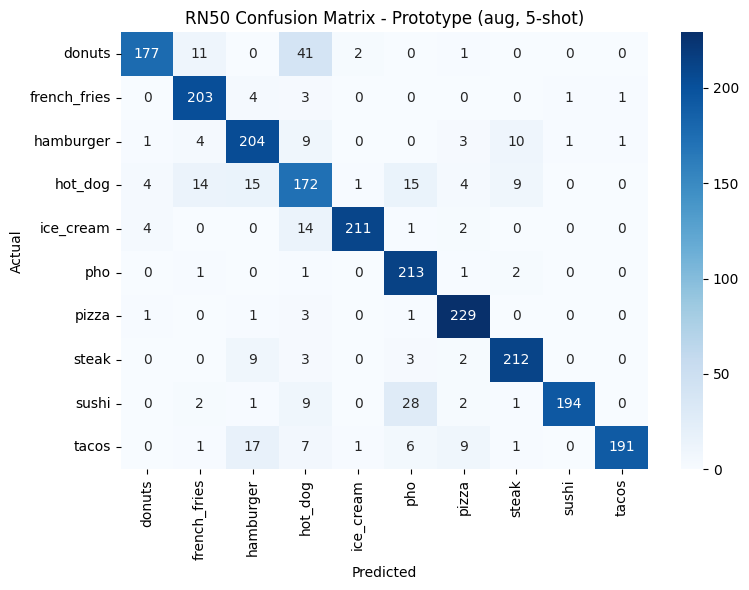

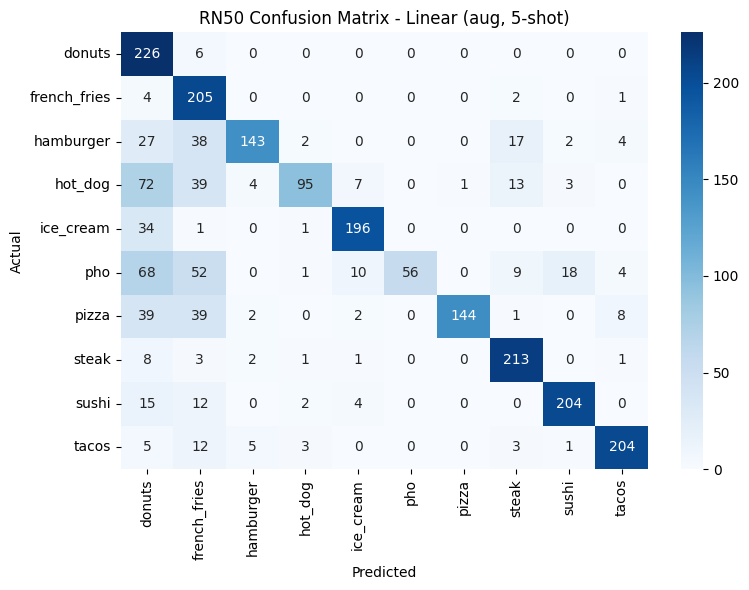

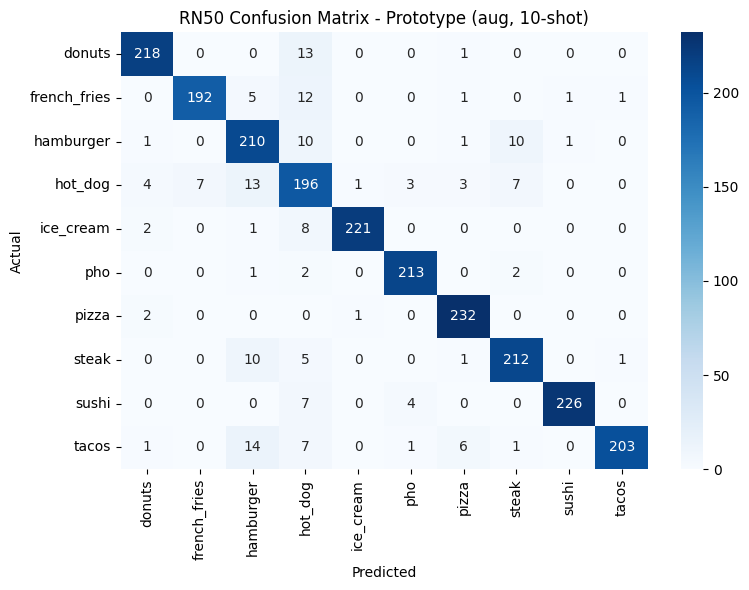

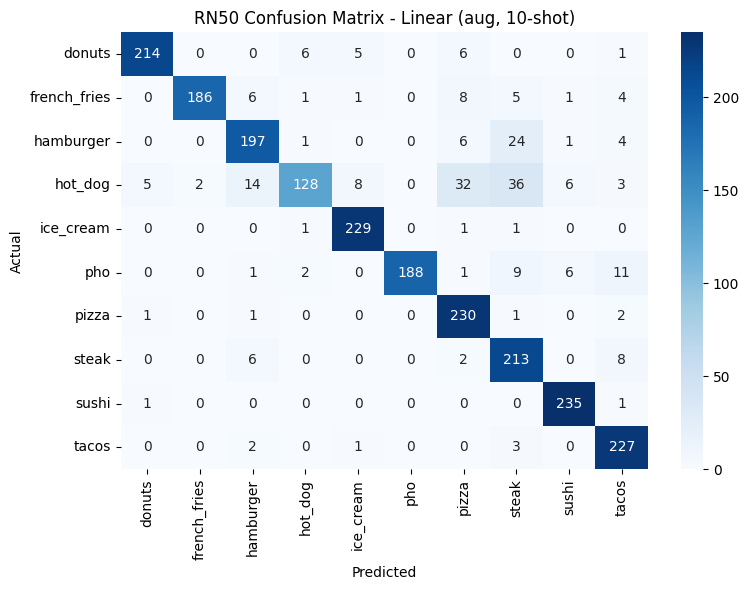


All RN50 comparison outputs were saved to: comparison_rn50_fewshot_5_10_proto_vs_linear_aug_noaug


In [20]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, confusion_matrix
import seaborn as sns

# =========================================================
# REQUIREMENTS
# - results_aug_compare must exist with structure:
#   results_aug_compare[setting][k]["prototype"]
#   results_aug_compare[setting][k]["linear"]
# - class_names should exist for confusion matrices
# - You should have run few-shot with RN50 backbone already
# =========================================================

output_dir = "comparison_rn50_fewshot_5_10_proto_vs_linear_aug_noaug"
os.makedirs(output_dir, exist_ok=True)

target_shots = [5, 10]
target_settings = ["no_aug", "aug"]
target_methods = ["prototype", "linear"]

rows = []

for setting_name in target_settings:
    if setting_name not in results_aug_compare:
        continue

    for k in target_shots:
        if k not in results_aug_compare[setting_name]:
            continue

        result_k = results_aug_compare[setting_name][k]

        for method_name in target_methods:
            if method_name not in result_k:
                continue

            m = result_k[method_name]
            preds = np.array(m["preds"]) if "preds" in m else None
            labels = np.array(m["labels"]) if "labels" in m else None

            if preds is not None and labels is not None and len(preds) > 0:
                precision_macro = precision_score(labels, preds, average="macro", zero_division=0)
            else:
                precision_macro = np.nan

            rows.append({
                "Backbone": "RN50",
                "Shot": k,
                "Setting": setting_name,
                "Method": method_name.capitalize(),  # Prototype / Linear
                "Accuracy": float(m["accuracy"]) if "accuracy" in m else np.nan,
                "Precision": float(precision_macro),
                "F1 Score": float(m["f1"]) if "f1" in m else np.nan
            })

df = pd.DataFrame(rows)

if df.empty:
    print("No matching data found. Please run RN50 few-shot experiments for 5-shot and 10-shot first.")
else:
    df = df.sort_values(["Shot", "Setting", "Method"]).reset_index(drop=True)

    print("=" * 110)
    print("RN50 COMPARISON: Few-shot (5 vs 10) | Prototype vs Linear | no_aug vs aug")
    print("=" * 110)
    print(df.round(4).to_string(index=False))

    # Save metrics table
    df.to_csv(os.path.join(output_dir, "rn50_fewshot_5_10_metrics.csv"), index=False, encoding="utf-8-sig")
    df.to_excel(os.path.join(output_dir, "rn50_fewshot_5_10_metrics.xlsx"), index=False)
    with open(os.path.join(output_dir, "rn50_fewshot_5_10_metrics.json"), "w", encoding="utf-8") as f:
        json.dump(df.to_dict(orient="records"), f, ensure_ascii=False, indent=2)

    # -------------------------
    # Plot 1: Accuracy (grouped bar)
    # -------------------------
    plot_df = df.copy()
    plot_df["Group"] = plot_df["Setting"] + " | " + plot_df["Shot"].astype(str) + "-shot"

    groups = sorted(
        plot_df["Group"].unique(),
        key=lambda x: (x.split(" | ")[0], int(x.split(" | ")[1].replace("-shot", "")))
    )
    x = np.arange(len(groups))
    width = 0.35

    acc_proto, acc_linear = [], []
    for g in groups:
        sub = plot_df[plot_df["Group"] == g]
        p = sub[sub["Method"] == "Prototype"]["Accuracy"]
        l = sub[sub["Method"] == "Linear"]["Accuracy"]
        acc_proto.append(float(p.values[0]) if len(p) else np.nan)
        acc_linear.append(float(l.values[0]) if len(l) else np.nan)

    plt.figure(figsize=(12, 6))
    bars1 = plt.bar(x - width / 2, acc_proto, width, label="Prototype", alpha=0.85)
    bars2 = plt.bar(x + width / 2, acc_linear, width, label="Linear", alpha=0.85)

    for bars in [bars1, bars2]:
        for b in bars:
            h = b.get_height()
            if not np.isnan(h):
                plt.text(b.get_x() + b.get_width() / 2, h + 0.01, f"{h:.3f}",
                         ha="center", va="bottom", fontsize=8)

    plt.xticks(x, groups, rotation=15, ha="right")
    plt.ylim([0, 1.05])
    plt.ylabel("Accuracy")
    plt.title("RN50 Few-shot: Accuracy (5-shot vs 10-shot, aug vs no_aug)")
    plt.grid(axis="y", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "rn50_accuracy_grouped.png"), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    # -------------------------
    # Plot 2: F1 Score (grouped bar)
    # -------------------------
    f1_proto, f1_linear = [], []
    for g in groups:
        sub = plot_df[plot_df["Group"] == g]
        p = sub[sub["Method"] == "Prototype"]["F1 Score"]
        l = sub[sub["Method"] == "Linear"]["F1 Score"]
        f1_proto.append(float(p.values[0]) if len(p) else np.nan)
        f1_linear.append(float(l.values[0]) if len(l) else np.nan)

    plt.figure(figsize=(12, 6))
    bars1 = plt.bar(x - width / 2, f1_proto, width, label="Prototype", alpha=0.85)
    bars2 = plt.bar(x + width / 2, f1_linear, width, label="Linear", alpha=0.85)

    for bars in [bars1, bars2]:
        for b in bars:
            h = b.get_height()
            if not np.isnan(h):
                plt.text(b.get_x() + b.get_width() / 2, h + 0.01, f"{h:.3f}",
                         ha="center", va="bottom", fontsize=8)

    plt.xticks(x, groups, rotation=15, ha="right")
    plt.ylim([0, 1.05])
    plt.ylabel("F1 Score")
    plt.title("RN50 Few-shot: F1 Score (5-shot vs 10-shot, aug vs no_aug)")
    plt.grid(axis="y", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "rn50_f1_grouped.png"), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    # -------------------------
    # Confusion matrices
    # -------------------------
    if "class_names" in globals():
        for setting_name in target_settings:
            if setting_name not in results_aug_compare:
                continue

            for k in target_shots:
                if k not in results_aug_compare[setting_name]:
                    continue

                for method_name in target_methods:
                    rr = results_aug_compare[setting_name][k]
                    if method_name not in rr:
                        continue

                    m = rr[method_name]
                    if "preds" not in m or "labels" not in m:
                        continue

                    preds = np.array(m["preds"])
                    labels = np.array(m["labels"])
                    cm = confusion_matrix(labels, preds)
                    cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

                    prefix = f"rn50_{setting_name}_{k}shot_{method_name}"
                    cm_df.to_csv(os.path.join(output_dir, f"{prefix}_confusion_matrix.csv"), encoding="utf-8-sig")
                    cm_df.to_excel(os.path.join(output_dir, f"{prefix}_confusion_matrix.xlsx"))

                    plt.figure(figsize=(8, 6))
                    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                                xticklabels=class_names, yticklabels=class_names)
                    plt.title(f"RN50 Confusion Matrix - {method_name.capitalize()} ({setting_name}, {k}-shot)")
                    plt.xlabel("Predicted")
                    plt.ylabel("Actual")
                    plt.tight_layout()
                    plt.savefig(os.path.join(output_dir, f"{prefix}_confusion_matrix.png"),
                                dpi=300, bbox_inches="tight")
                    plt.show()
                    plt.close()

    print(f"\nAll RN50 comparison outputs were saved to: {output_dir}")


COMPARISON: Zero-Shot vs Few-Shot (no_aug / aug)
          Method   Setting  Shot  Accuracy  Precision  F1 Score
       Zero-Shot zero_shot     0    0.8959     0.8981    0.8769
 5-Shot (no_aug)    no_aug     5    0.7895     0.8323    0.7891
10-Shot (no_aug)    no_aug    10    0.8898     0.9027    0.8885
    5-Shot (aug)       aug     5    0.7346     0.8302    0.7286
   10-Shot (aug)       aug    10    0.8919     0.9032    0.8888


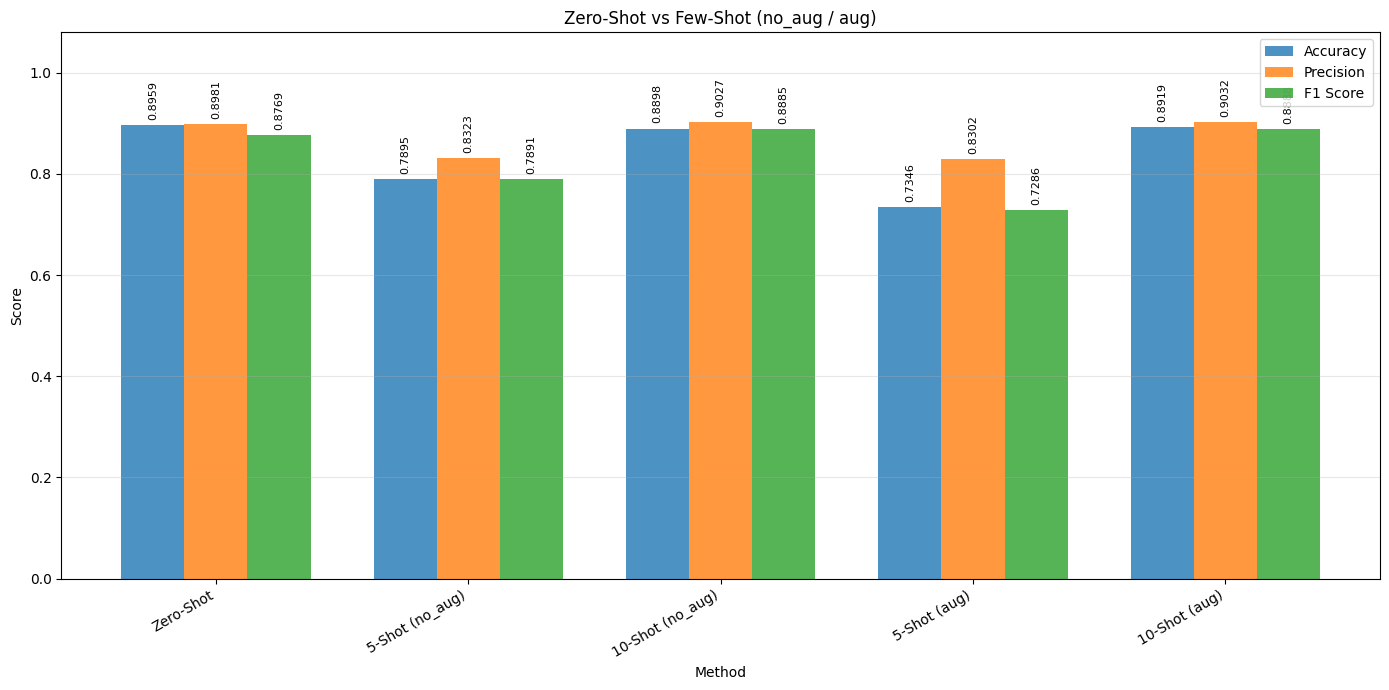

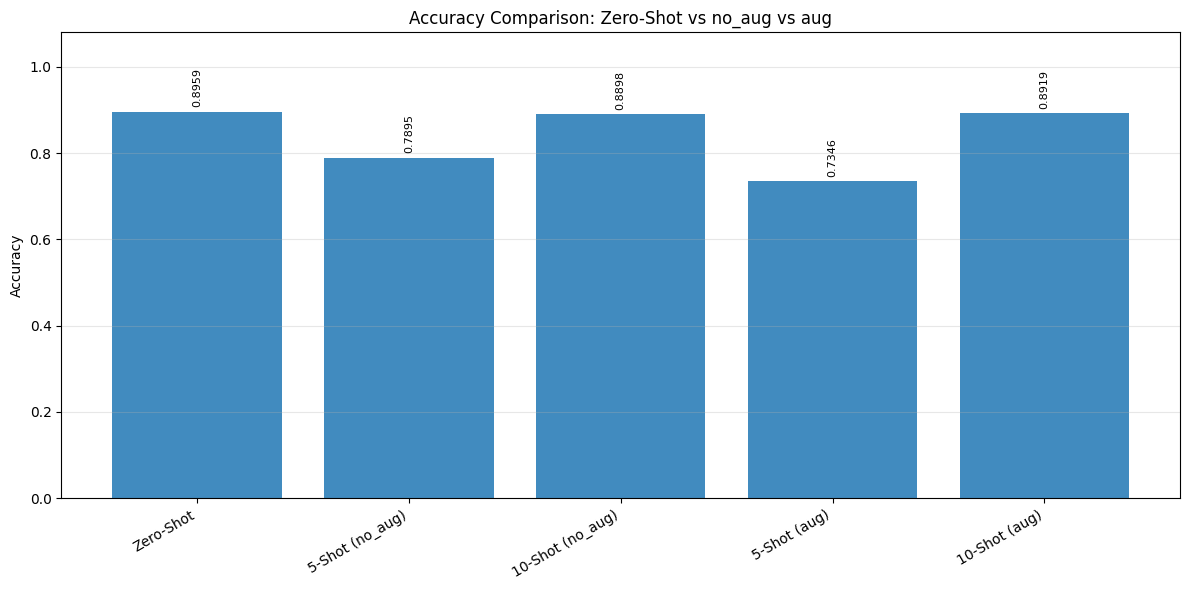

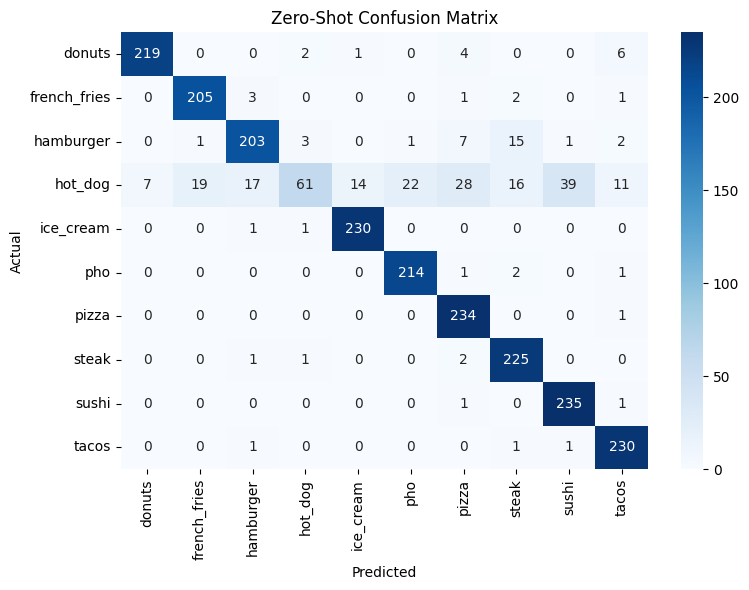

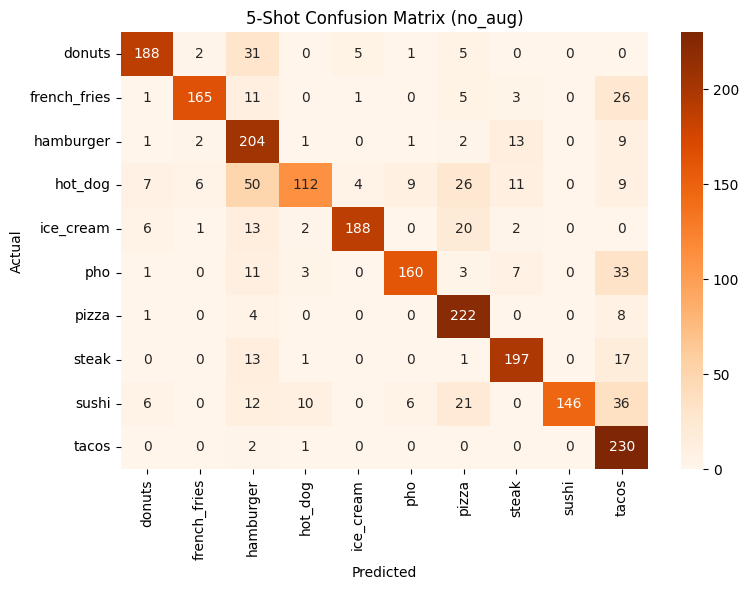

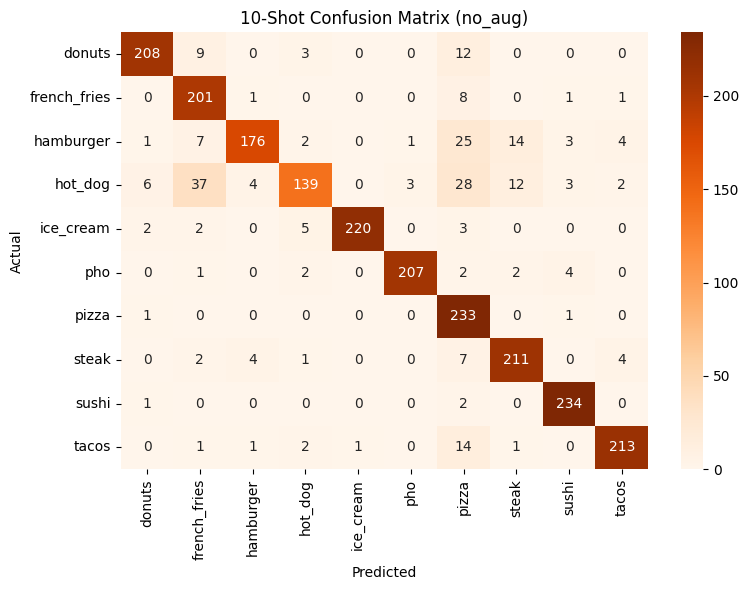

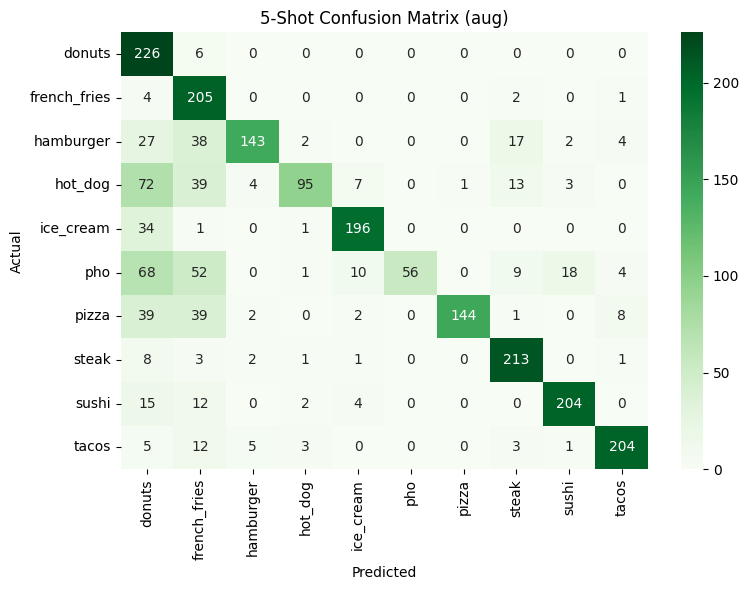

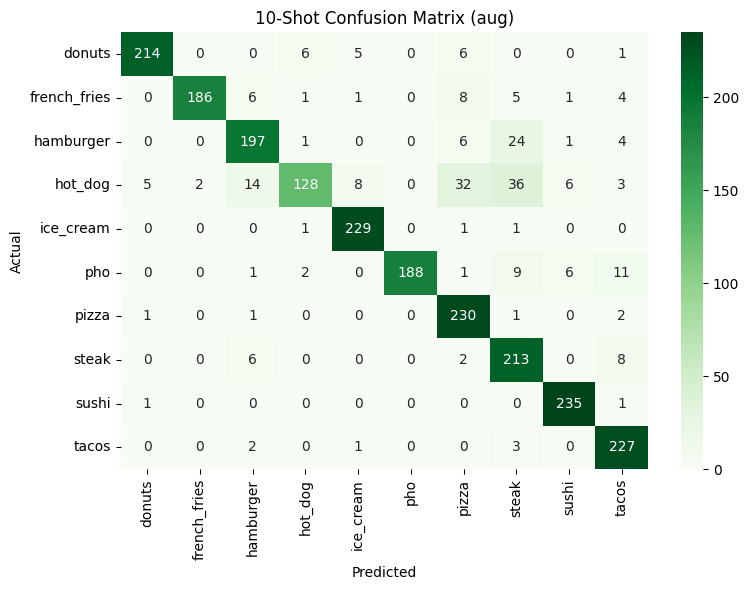

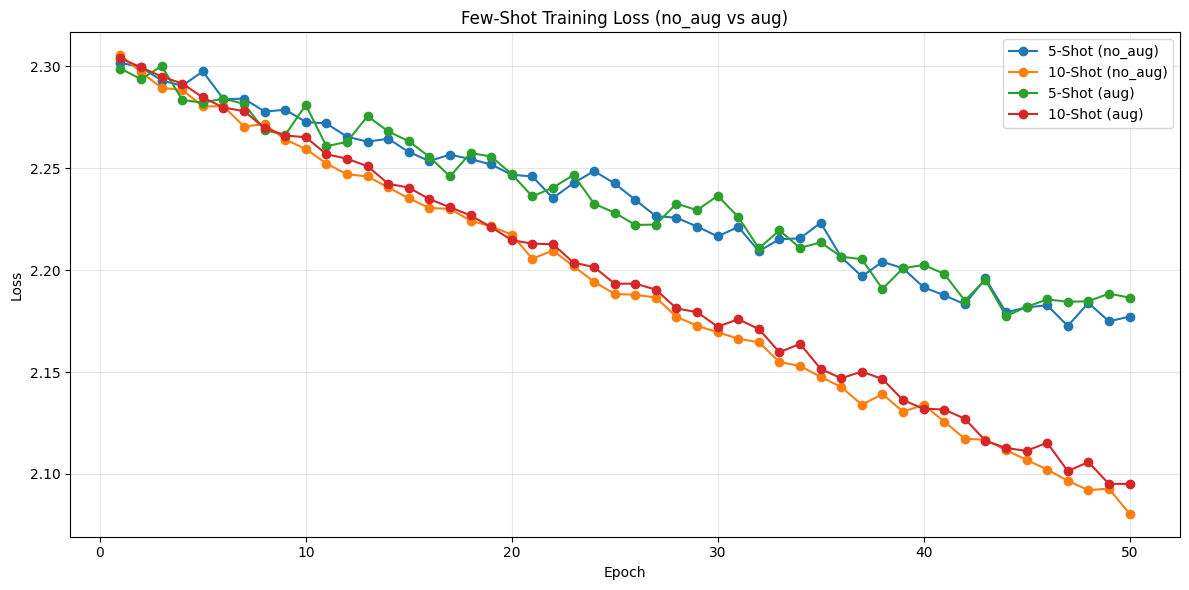

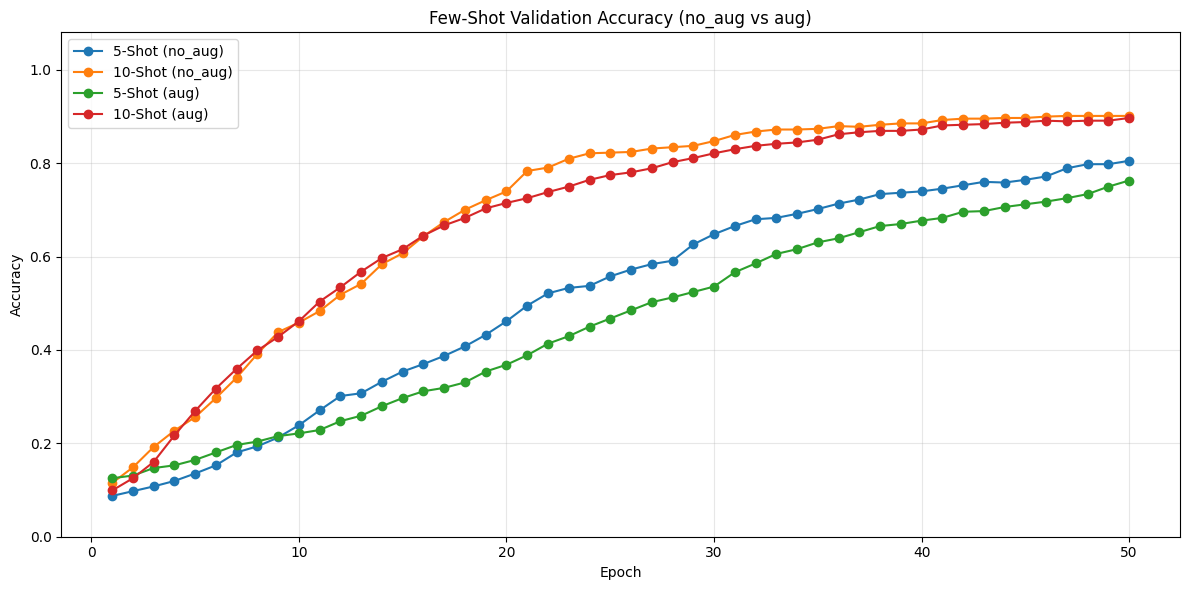


Đã xuất toàn bộ file vào thư mục: comparison_outputs_aug_vs_noaug
Đã tạo file nén: comparison_outputs_aug_vs_noaug.zip

Danh sách file đã tạo:
- accuracy_comparison_all.png
- aug_10_shot_confusion_matrix.csv
- aug_10_shot_confusion_matrix.png
- aug_10_shot_confusion_matrix.xlsx
- aug_10_shot_predictions.csv
- aug_10_shot_train_losses.csv
- aug_10_shot_val_accuracies.csv
- aug_5_shot_confusion_matrix.csv
- aug_5_shot_confusion_matrix.png
- aug_5_shot_confusion_matrix.xlsx
- aug_5_shot_predictions.csv
- aug_5_shot_train_losses.csv
- aug_5_shot_val_accuracies.csv
- comparison_metrics_all.csv
- comparison_metrics_all.json
- comparison_metrics_all.xlsx
- comparison_summary.txt
- few_shot_training_loss_all.png
- few_shot_validation_accuracy_all.png
- metrics_comparison_all.png
- no_aug_10_shot_confusion_matrix.csv
- no_aug_10_shot_confusion_matrix.png
- no_aug_10_shot_confusion_matrix.xlsx
- no_aug_10_shot_predictions.csv
- no_aug_10_shot_train_losses.csv
- no_aug_10_shot_val_accuracies.csv

In [21]:
import os
import json
import pickle
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_score
import seaborn as sns

# =========================
# 0) Kiểm tra biến đầu vào
# =========================
required_vars = [
    "accuracy_zero_shot",
    "f1_zero_shot",
    "preds_zero_shot",
    "labels_zero_shot",
    "results_aug_compare",
    "class_names"
]

missing_vars = [v for v in required_vars if v not in globals()]

if len(missing_vars) == 0:
    output_dir = "comparison_outputs_aug_vs_noaug"
    os.makedirs(output_dir, exist_ok=True)

    # =========================
    # 1) Precision Zero-Shot
    # =========================
    precision_zero_shot = precision_score(
        labels_zero_shot,
        preds_zero_shot,
        average="macro",
        zero_division=0
    )

    # =========================
    # 2) Tạo bảng so sánh tổng
    # =========================
    results_rows = [
        {
            "Method": "Zero-Shot",
            "Setting": "zero_shot",
            "Shot": 0,
            "Accuracy": float(accuracy_zero_shot),
            "Precision": float(precision_zero_shot),
            "F1 Score": float(f1_zero_shot)
        }
    ]

    for setting_name in ["no_aug", "aug"]:
        if setting_name in results_aug_compare:
            for k in [5, 10]:
                if k in results_aug_compare[setting_name]:
                    r = results_aug_compare[setting_name][k]

                    if "preds" in r and "labels" in r:
                        precision_k = precision_score(
                            r["labels"],
                            r["preds"],
                            average="macro",
                            zero_division=0
                        )
                    else:
                        precision_k = np.nan

                    results_rows.append({
                        "Method": f"{k}-Shot ({setting_name})",
                        "Setting": setting_name,
                        "Shot": k,
                        "Accuracy": float(r["accuracy"]) if "accuracy" in r else np.nan,
                        "Precision": float(precision_k),
                        "F1 Score": float(r["f1"]) if "f1" in r else np.nan
                    })

    results_df = pd.DataFrame(results_rows)

    print("\n" + "=" * 110)
    print("COMPARISON: Zero-Shot vs Few-Shot (no_aug / aug)")
    print("=" * 110)
    print(results_df.round(4).to_string(index=False))

    # =========================
    # 3) Xuất bảng metrics
    # =========================
    results_df.to_csv(
        os.path.join(output_dir, "comparison_metrics_all.csv"),
        index=False,
        encoding="utf-8-sig"
    )
    results_df.to_excel(
        os.path.join(output_dir, "comparison_metrics_all.xlsx"),
        index=False
    )

    with open(os.path.join(output_dir, "comparison_metrics_all.json"), "w", encoding="utf-8") as f:
        json.dump(results_rows, f, ensure_ascii=False, indent=2)

    # =========================
    # 4) Zero-shot confusion matrix + predictions
    # =========================
    cm_zero_shot = confusion_matrix(labels_zero_shot, preds_zero_shot)
    cm_zero_df = pd.DataFrame(cm_zero_shot, index=class_names, columns=class_names)

    cm_zero_df.to_csv(
        os.path.join(output_dir, "zero_shot_confusion_matrix.csv"),
        encoding="utf-8-sig"
    )
    cm_zero_df.to_excel(
        os.path.join(output_dir, "zero_shot_confusion_matrix.xlsx")
    )

    zero_pred_df = pd.DataFrame({
        "true_label": labels_zero_shot,
        "pred_label": preds_zero_shot
    })
    zero_pred_df.to_csv(
        os.path.join(output_dir, "zero_shot_predictions.csv"),
        index=False,
        encoding="utf-8-sig"
    )

    # =========================
    # 5) Xuất dữ liệu từng no_aug / aug
    # =========================
    for setting_name in ["no_aug", "aug"]:
        if setting_name in results_aug_compare:
            for k in [5, 10]:
                if k in results_aug_compare[setting_name]:
                    r = results_aug_compare[setting_name][k]
                    prefix = f"{setting_name}_{k}_shot"

                    # Train losses
                    if "train_losses" in r:
                        loss_df = pd.DataFrame({
                            "epoch": range(1, len(r["train_losses"]) + 1),
                            "train_loss": r["train_losses"]
                        })
                        loss_df.to_csv(
                            os.path.join(output_dir, f"{prefix}_train_losses.csv"),
                            index=False,
                            encoding="utf-8-sig"
                        )

                    # Validation accuracies
                    if "val_accuracies" in r:
                        val_df = pd.DataFrame({
                            "epoch": range(1, len(r["val_accuracies"]) + 1),
                            "val_accuracy": r["val_accuracies"]
                        })
                        val_df.to_csv(
                            os.path.join(output_dir, f"{prefix}_val_accuracies.csv"),
                            index=False,
                            encoding="utf-8-sig"
                        )

                    # Predictions + confusion matrix
                    if "preds" in r and "labels" in r:
                        pred_df = pd.DataFrame({
                            "true_label": r["labels"],
                            "pred_label": r["preds"]
                        })
                        pred_df.to_csv(
                            os.path.join(output_dir, f"{prefix}_predictions.csv"),
                            index=False,
                            encoding="utf-8-sig"
                        )

                        cm_k = confusion_matrix(r["labels"], r["preds"])
                        cm_k_df = pd.DataFrame(cm_k, index=class_names, columns=class_names)

                        cm_k_df.to_csv(
                            os.path.join(output_dir, f"{prefix}_confusion_matrix.csv"),
                            encoding="utf-8-sig"
                        )
                        cm_k_df.to_excel(
                            os.path.join(output_dir, f"{prefix}_confusion_matrix.xlsx")
                        )

    # =========================
    # 6) Vẽ hình
    # =========================

    # (a) Metrics comparison
    plt.figure(figsize=(14, 7))
    methods = results_df["Method"].values
    accuracies = results_df["Accuracy"].values
    precisions = results_df["Precision"].values
    f1_scores = results_df["F1 Score"].values

    x = np.arange(len(methods))
    width = 0.25

    bars1 = plt.bar(x - width, accuracies, width, label="Accuracy", alpha=0.8)
    bars2 = plt.bar(x, precisions, width, label="Precision", alpha=0.8)
    bars3 = plt.bar(x + width, f1_scores, width, label="F1 Score", alpha=0.8)

    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            h = bar.get_height()
            if not np.isnan(h):
                plt.text(
                    bar.get_x() + bar.get_width() / 2,
                    h + 0.01,
                    f"{h:.4f}",
                    ha="center",
                    va="bottom",
                    fontsize=8,
                    rotation=90
                )

    plt.xlabel("Method")
    plt.ylabel("Score")
    plt.title("Zero-Shot vs Few-Shot (no_aug / aug)")
    plt.xticks(x, methods, rotation=30, ha="right")
    plt.ylim([0, 1.08])
    plt.grid(axis="y", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(
        os.path.join(output_dir, "metrics_comparison_all.png"),
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()
    plt.close()

    # (b) Accuracy only comparison
    plt.figure(figsize=(12, 6))
    plt.bar(results_df["Method"], results_df["Accuracy"], alpha=0.85)
    for i, v in enumerate(results_df["Accuracy"]):
        if not np.isnan(v):
            plt.text(i, v + 0.01, f"{v:.4f}", ha="center", va="bottom", fontsize=8, rotation=90)
    plt.ylabel("Accuracy")
    plt.title("Accuracy Comparison: Zero-Shot vs no_aug vs aug")
    plt.ylim([0, 1.08])
    plt.xticks(rotation=30, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(
        os.path.join(output_dir, "accuracy_comparison_all.png"),
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()
    plt.close()

    # (c) Zero-shot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm_zero_shot,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title("Zero-Shot Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig(
        os.path.join(output_dir, "zero_shot_confusion_matrix.png"),
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()
    plt.close()

    # (d) Few-shot confusion matrix cho no_aug / aug
    for setting_name in ["no_aug", "aug"]:
        if setting_name in results_aug_compare:
            for k in [5, 10]:
                if k in results_aug_compare[setting_name]:
                    r = results_aug_compare[setting_name][k]
                    if "preds" in r and "labels" in r:
                        cm_k = confusion_matrix(r["labels"], r["preds"])

                        plt.figure(figsize=(8, 6))
                        sns.heatmap(
                            cm_k,
                            annot=True,
                            fmt="d",
                            cmap="Greens" if setting_name == "aug" else "Oranges",
                            xticklabels=class_names,
                            yticklabels=class_names
                        )
                        plt.title(f"{k}-Shot Confusion Matrix ({setting_name})")
                        plt.xlabel("Predicted")
                        plt.ylabel("Actual")
                        plt.tight_layout()
                        plt.savefig(
                            os.path.join(output_dir, f"{setting_name}_{k}_shot_confusion_matrix.png"),
                            dpi=300,
                            bbox_inches="tight"
                        )
                        plt.show()
                        plt.close()

    # (e) Training loss comparison
    plt.figure(figsize=(12, 6))
    plotted = False
    for setting_name in ["no_aug", "aug"]:
        if setting_name in results_aug_compare:
            for k in [5, 10]:
                if k in results_aug_compare[setting_name]:
                    r = results_aug_compare[setting_name][k]
                    if "train_losses" in r:
                        epochs = range(1, len(r["train_losses"]) + 1)
                        plt.plot(epochs, r["train_losses"], marker="o", label=f"{k}-Shot ({setting_name})")
                        plotted = True

    if plotted:
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Few-Shot Training Loss (no_aug vs aug)")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.savefig(
            os.path.join(output_dir, "few_shot_training_loss_all.png"),
            dpi=300,
            bbox_inches="tight"
        )
        plt.show()
        plt.close()
    else:
        plt.close()

    # (f) Validation accuracy comparison
    plt.figure(figsize=(12, 6))
    plotted = False
    for setting_name in ["no_aug", "aug"]:
        if setting_name in results_aug_compare:
            for k in [5, 10]:
                if k in results_aug_compare[setting_name]:
                    r = results_aug_compare[setting_name][k]
                    if "val_accuracies" in r:
                        epochs = range(1, len(r["val_accuracies"]) + 1)
                        plt.plot(epochs, r["val_accuracies"], marker="o", label=f"{k}-Shot ({setting_name})")
                        plotted = True

    if plotted:
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title("Few-Shot Validation Accuracy (no_aug vs aug)")
        plt.ylim([0, 1.08])
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.savefig(
            os.path.join(output_dir, "few_shot_validation_accuracy_all.png"),
            dpi=300,
            bbox_inches="tight"
        )
        plt.show()
        plt.close()
    else:
        plt.close()

    # =========================
    # 7) Xuất file tóm tắt txt
    # =========================
    summary_lines = []
    summary_lines.append("=" * 110)
    summary_lines.append("COMPARISON: Zero-Shot vs Few-Shot (no_aug / aug)")
    summary_lines.append("=" * 110)
    summary_lines.append(results_df.round(4).to_string(index=False))
    summary_lines.append("")

    summary_lines.append("[Zero-Shot]")
    summary_lines.append(f"Accuracy : {accuracy_zero_shot:.4f}")
    summary_lines.append(f"Precision: {precision_zero_shot:.4f}")
    summary_lines.append(f"F1 Score : {f1_zero_shot:.4f}")
    summary_lines.append("")

    for setting_name in ["no_aug", "aug"]:
        if setting_name in results_aug_compare:
            summary_lines.append(f"[{setting_name.upper()}]")
            for k in [5, 10]:
                if k in results_aug_compare[setting_name]:
                    r = results_aug_compare[setting_name][k]

                    summary_lines.append(f"  [{k}-Shot]")
                    if "accuracy" in r:
                        summary_lines.append(f"  Accuracy : {r['accuracy']:.4f}")
                    if "preds" in r and "labels" in r:
                        precision_k = precision_score(
                            r["labels"],
                            r["preds"],
                            average="macro",
                            zero_division=0
                        )
                        summary_lines.append(f"  Precision: {precision_k:.4f}")
                    if "f1" in r:
                        summary_lines.append(f"  F1 Score : {r['f1']:.4f}")
                    if "train_losses" in r and len(r["train_losses"]) > 0:
                        summary_lines.append(f"  Train Loss cuối   : {r['train_losses'][-1]:.6f}")
                    if "val_accuracies" in r and len(r["val_accuracies"]) > 0:
                        summary_lines.append(f"  Val Accuracy cuối : {r['val_accuracies'][-1]:.4f}")
                    summary_lines.append("")

    with open(os.path.join(output_dir, "comparison_summary.txt"), "w", encoding="utf-8") as f:
        f.write("\n".join(summary_lines))

    # =========================
    # 8) Lưu raw object
    # =========================
    export_bundle = {
        "accuracy_zero_shot": accuracy_zero_shot,
        "precision_zero_shot": precision_zero_shot,
        "f1_zero_shot": f1_zero_shot,
        "preds_zero_shot": np.array(preds_zero_shot),
        "labels_zero_shot": np.array(labels_zero_shot),
        "results_aug_compare": results_aug_compare,
        "class_names": class_names
    }

    with open(os.path.join(output_dir, "raw_results_bundle.pkl"), "wb") as f:
        pickle.dump(export_bundle, f)

    # =========================
    # 9) Nén toàn bộ thư mục output
    # =========================
    zip_path = "comparison_outputs_aug_vs_noaug.zip"
    with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files in os.walk(output_dir):
            for file in files:
                full_path = os.path.join(root, file)
                arcname = os.path.relpath(full_path, start=".")
                zipf.write(full_path, arcname)

    print("\nĐã xuất toàn bộ file vào thư mục:", output_dir)
    print("Đã tạo file nén:", zip_path)

    print("\nDanh sách file đã tạo:")
    for file_name in sorted(os.listdir(output_dir)):
        print("-", file_name)

else:
    print("Thiếu các biến sau:")
    for v in missing_vars:
        print(f"- {v}")
    print("\nHãy chạy lại zero-shot và few-shot aug/no_aug trước.")


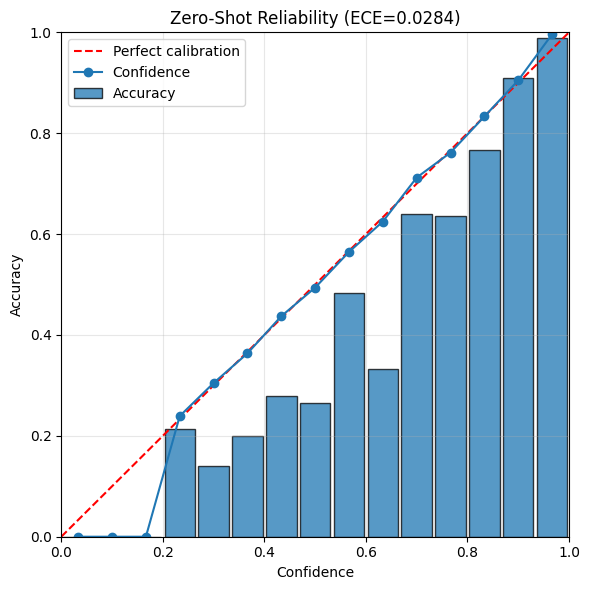

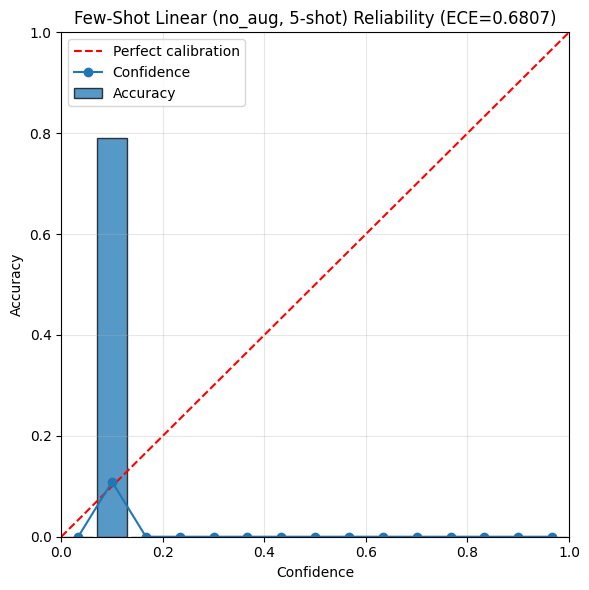

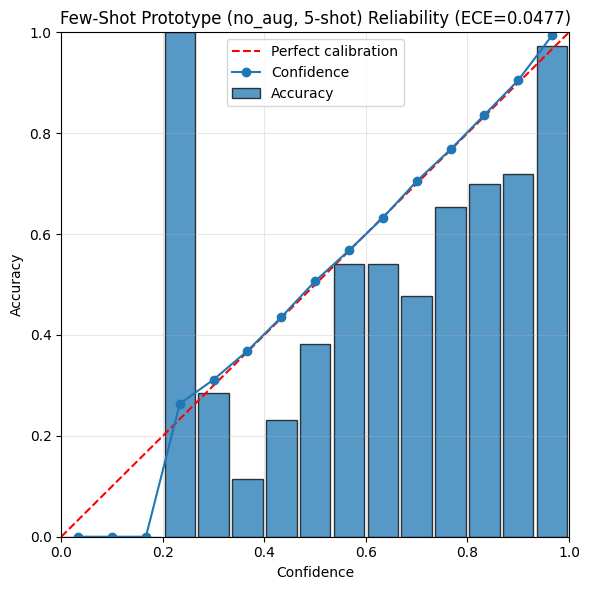

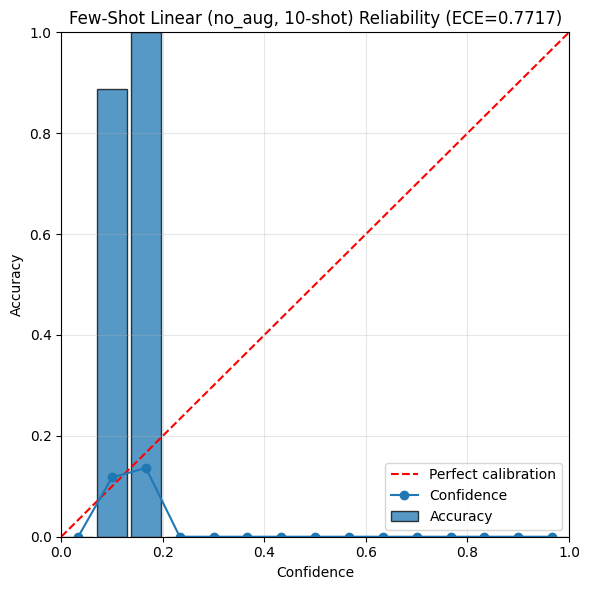

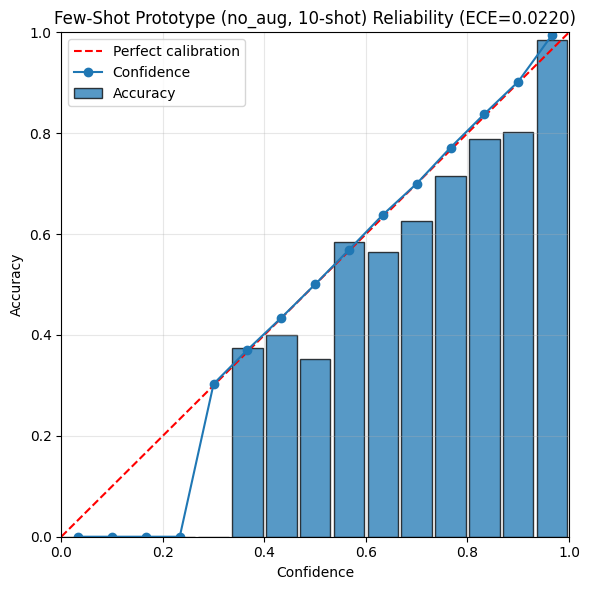

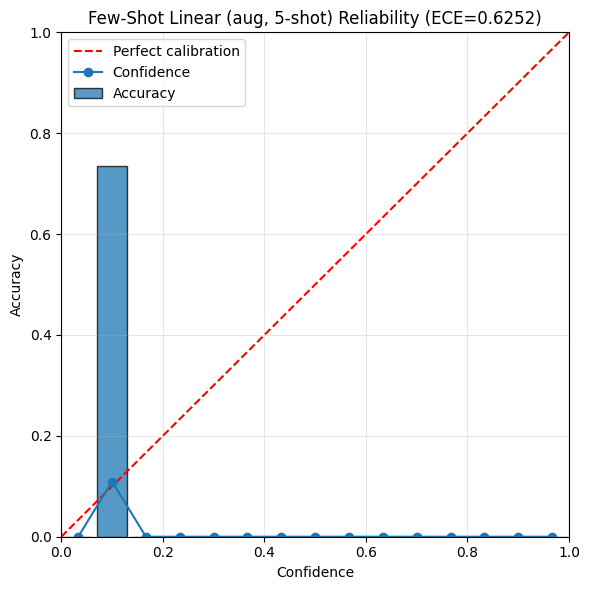

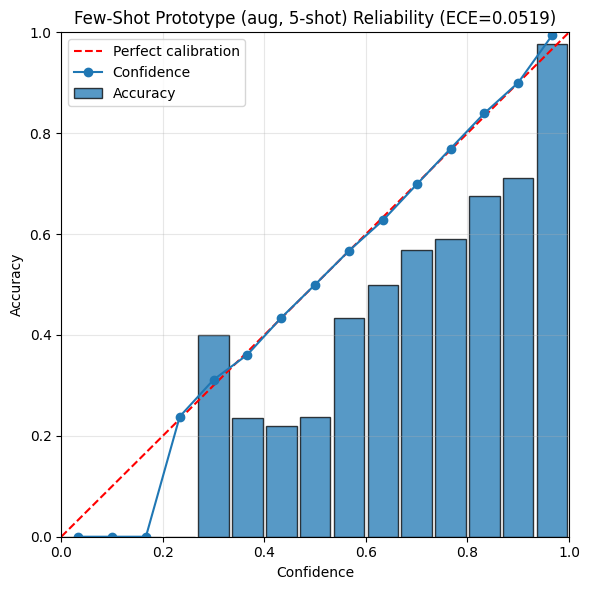

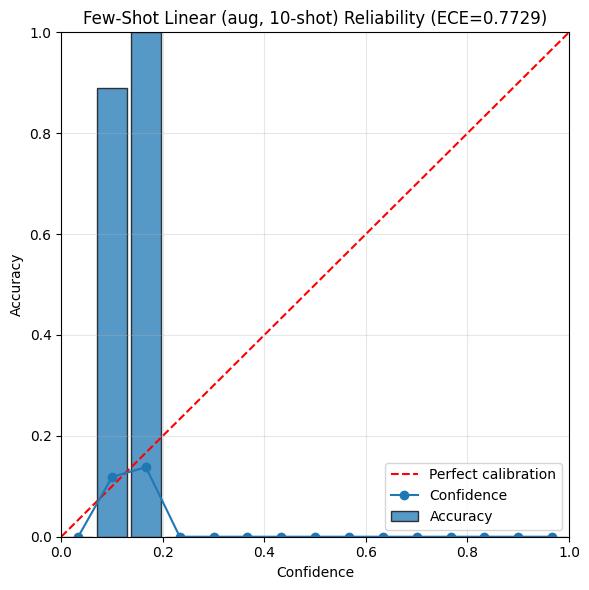

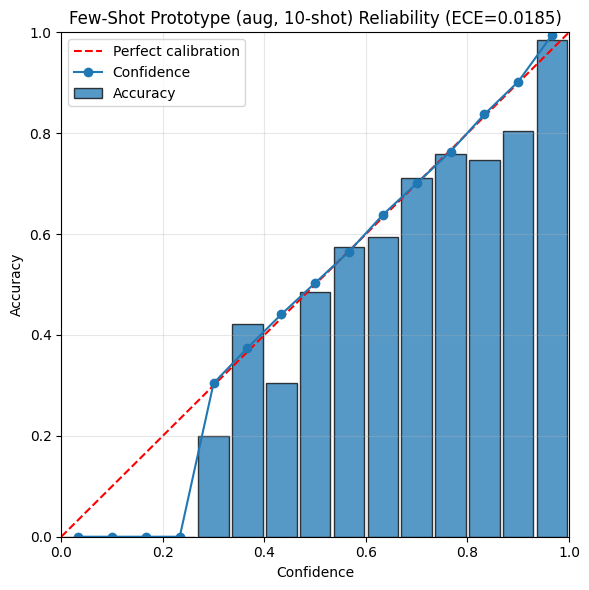


=== CALIBRATION SUMMARY (lower ECE is better) ===
                               Model      ECE  Confidently_Correct@0.9
   Few-Shot Prototype (aug, 10-shot) 0.018536                 0.822222
Few-Shot Prototype (no_aug, 10-shot) 0.022023                 0.823094
                           Zero-Shot 0.028367                 0.825708
 Few-Shot Prototype (no_aug, 5-shot) 0.047686                 0.779521
    Few-Shot Prototype (aug, 5-shot) 0.051852                 0.772113
       Few-Shot Linear (aug, 5-shot) 0.625190                 0.000000
    Few-Shot Linear (no_aug, 5-shot) 0.680664                 0.000000
   Few-Shot Linear (no_aug, 10-shot) 0.771729                 0.000000
      Few-Shot Linear (aug, 10-shot) 0.772886                 0.000000

Saved to: calibration_outputs


In [22]:
# =========================
# CALIBRATION: ECE + RELIABILITY + CONFIDENTLY CORRECT
# =========================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

# ---------- Helpers ----------
def compute_ece(confidences, preds, labels, n_bins=15):
    confidences = np.asarray(confidences)
    preds = np.asarray(preds)
    labels = np.asarray(labels)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    bin_accs, bin_confs, bin_counts = [], [], []

    for i in range(n_bins):
        left, right = bins[i], bins[i + 1]
        if i == n_bins - 1:
            mask = (confidences >= left) & (confidences <= right)
        else:
            mask = (confidences >= left) & (confidences < right)

        if np.any(mask):
            acc = (preds[mask] == labels[mask]).mean()
            conf = confidences[mask].mean()
            cnt = int(mask.sum())
        else:
            acc, conf, cnt = 0.0, 0.0, 0

        ece += (cnt / len(confidences)) * abs(acc - conf)
        bin_accs.append(acc)
        bin_confs.append(conf)
        bin_counts.append(cnt)

    return float(ece), np.array(bin_accs), np.array(bin_confs), np.array(bin_counts), bins


def evaluate_with_confidence(model, data_loader, device="cuda"):
    model.eval()
    all_preds, all_labels, all_confidences = [], [], []

    with torch.no_grad():
        for images, texts, labels in data_loader:
            images = images.to(device)
            logits = model(images, texts)
            probs = torch.softmax(logits, dim=1)
            confs, preds = torch.max(probs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_confidences.extend(confs.cpu().numpy())

    return np.array(all_preds), np.array(all_labels), np.array(all_confidences)


def plot_reliability(bin_accs, bin_confs, bins, title, save_path):
    centers = (bins[:-1] + bins[1:]) / 2.0
    width = (bins[1] - bins[0]) * 0.9

    plt.figure(figsize=(6, 6))
    plt.bar(centers, bin_accs, width=width, alpha=0.75, edgecolor="black", label="Accuracy")
    plt.plot([0, 1], [0, 1], "--", color="red", label="Perfect calibration")
    plt.plot(centers, bin_confs, marker="o", linewidth=1.5, label="Confidence")
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.xlabel("Confidence")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()


# ---------- Main ----------
output_dir = "calibration_outputs"
os.makedirs(output_dir, exist_ok=True)

calibration_rows = []

# 1) Zero-shot (needs preds_zero_shot, labels_zero_shot, confidences_zero_shot)
if all(v in globals() for v in ["preds_zero_shot", "labels_zero_shot", "confidences_zero_shot"]):
    ece_zs, bacc, bconf, bcnt, bins = compute_ece(
        confidences_zero_shot, preds_zero_shot, labels_zero_shot, n_bins=15
    )
    cc_zs = float(((np.array(preds_zero_shot) == np.array(labels_zero_shot)) &
                   (np.array(confidences_zero_shot) >= 0.9)).mean())

    calibration_rows.append({
        "Model": "Zero-Shot",
        "ECE": ece_zs,
        "Confidently_Correct@0.9": cc_zs
    })

    plot_reliability(
        bacc, bconf, bins,
        title=f"Zero-Shot Reliability (ECE={ece_zs:.4f})",
        save_path=os.path.join(output_dir, "reliability_zero_shot.png")
    )

# 2) Few-shot (Linear + Prototype from results_aug_compare)
# Expected structure:
# results_aug_compare[setting][k]["linear"]["model"]
# results_aug_compare[setting][k]["prototype"]["model"]
if "results_aug_compare" in globals():
    for setting_name, by_k in results_aug_compare.items():
        for k, r in by_k.items():

            # Linear
            if isinstance(r, dict) and "linear" in r and "model" in r["linear"]:
                model = r["linear"]["model"]
                preds, labels, confs = evaluate_with_confidence(model, test_loader, device=device)

                ece, bacc, bconf, bcnt, bins = compute_ece(confs, preds, labels, n_bins=15)
                cc = float(((preds == labels) & (confs >= 0.9)).mean())
                name = f"Few-Shot Linear ({setting_name}, {k}-shot)"

                calibration_rows.append({
                    "Model": name,
                    "ECE": ece,
                    "Confidently_Correct@0.9": cc
                })

                plot_reliability(
                    bacc, bconf, bins,
                    title=f"{name} Reliability (ECE={ece:.4f})",
                    save_path=os.path.join(output_dir, f"reliability_linear_{setting_name}_{k}shot.png")
                )

            # Prototype
            if isinstance(r, dict) and "prototype" in r and "model" in r["prototype"]:
                model = r["prototype"]["model"]
                preds, labels, confs = evaluate_with_confidence(model, test_loader, device=device)

                ece, bacc, bconf, bcnt, bins = compute_ece(confs, preds, labels, n_bins=15)
                cc = float(((preds == labels) & (confs >= 0.9)).mean())
                name = f"Few-Shot Prototype ({setting_name}, {k}-shot)"

                calibration_rows.append({
                    "Model": name,
                    "ECE": ece,
                    "Confidently_Correct@0.9": cc
                })

                plot_reliability(
                    bacc, bconf, bins,
                    title=f"{name} Reliability (ECE={ece:.4f})",
                    save_path=os.path.join(output_dir, f"reliability_prototype_{setting_name}_{k}shot.png")
                )

# Save summary table
if len(calibration_rows) > 0:
    calib_df = pd.DataFrame(calibration_rows).sort_values(by="ECE", ascending=True).reset_index(drop=True)

    print("\n=== CALIBRATION SUMMARY (lower ECE is better) ===")
    print(calib_df.to_string(index=False))

    calib_df.to_csv(os.path.join(output_dir, "calibration_summary.csv"), index=False, encoding="utf-8-sig")
    calib_df.to_excel(os.path.join(output_dir, "calibration_summary.xlsx"), index=False)
    print(f"\nSaved to: {output_dir}")
else:
    print("No calibration data found. Please run zero-shot/few-shot first.")